# ESMDance Embedding Pipeline for GPCR Multistate Prediction

This notebook computes protein-level embeddings using pretrained protein language models
and evaluates whether they can predict single-state vs multi-state behavior in MD simulations.

**ESMDance** is a dynamics-aware protein language model trained on MD simulations of 64,000+ proteins.
Unlike our handcrafted features (RMSD, graph topology, structural features), it brings external
knowledge about protein dynamics from pretraining.

**ESM-2** is a standard protein language model (no dynamics awareness) used as a baseline.

Pipeline:
1. Extract amino acid sequences from topology files
2. Compute embeddings (ESMDance or ESM-2)
3. Train static classifiers (LR, RF, MLP) with cross-protein evaluation

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings

# Paths — adjust these for your setup
METADATA_CSV = "../data/metadata/metadata.csv"
TOPOLOGY_DIR = Path("../../gcs_mount/data/topologies")
OUTPUT_DIR = Path("../data/processed_v4")
RESULTS_DIR = Path("../results/esmdance")

FASTA_PATH = OUTPUT_DIR / "gpcr_sequences.fasta"
EMBEDDING_DIR_ESMDANCE = OUTPUT_DIR / "esmdance_embeddings"
EMBEDDING_DIR_ESM2 = OUTPUT_DIR / "esm2_embeddings"

# Cross-protein holdout families (same as other experiments)
HOLDOUT_FAMILIES = ["Peptide", "Adenosine", "Serotonin"]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Metadata: {METADATA_CSV}")
print(f"Topology dir: {TOPOLOGY_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Metadata: ../data/metadata/metadata.csv
Topology dir: ../../gcs_mount/data/topologies
Output dir: ../data/processed_v4


## Step 1: Extract Sequences from Topology Files

Each GPCR has a topology file (PSF or TOP) containing atom information.
We extract the amino acid sequence by selecting CA atoms and mapping
3-letter residue codes to 1-letter codes.

In [5]:
import MDAnalysis as mda

THREE_TO_ONE = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    # Common variants in MD topology files
    'HSE': 'H', 'HSD': 'H', 'HSP': 'H',  # histidine protonation states
    'CYX': 'C', 'HIE': 'H', 'HID': 'H', 'HIP': 'H',
    'ASH': 'D', 'GLH': 'E',  # protonated Asp/Glu
}

def extract_sequence(topology_path):
    """Extract amino acid sequence from a topology file."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        u = mda.Universe(str(topology_path))
    ca = u.select_atoms('protein and name CA')
    resnames = [r.resname for r in ca.residues]
    unknowns = [r for r in resnames if r not in THREE_TO_ONE]
    seq = ''.join(THREE_TO_ONE.get(r, 'X') for r in resnames)
    return seq, len(resnames), unknowns

In [6]:
df = pd.read_csv(METADATA_CSV)
unique_receptors = df['receptor'].unique()
print(f"Total trajectories: {len(df)}")
print(f"Unique receptors: {len(unique_receptors)}")

# Build receptor → topology file mapping from metadata
receptor_to_top = {}
if 'top_file' in df.columns:
    for _, row in df.iterrows():
        rec = row['receptor']
        if rec not in receptor_to_top and pd.notna(row.get('top_file')):
            top_path = TOPOLOGY_DIR / row['top_file']
            if top_path.exists():
                receptor_to_top[rec] = top_path

# Fallback: search by receptor name in topology directory
all_tops = list(TOPOLOGY_DIR.glob("*.psf")) + list(TOPOLOGY_DIR.glob("*.top"))
print(f"Found {len(all_tops)} topology files")
print(f"Mapped {len(receptor_to_top)} receptors from metadata")

for receptor in unique_receptors:
    if receptor in receptor_to_top:
        continue
    receptor_lower = receptor.replace('~', '_').lower()
    for top_file in all_tops:
        if receptor_lower in top_file.name.replace('~', '_').lower():
            receptor_to_top[receptor] = top_file
            break

print(f"Total mapped: {len(receptor_to_top)}/{len(unique_receptors)}")

Total trajectories: 247
Unique receptors: 144
Found 474 topology files
Mapped 143 receptors from metadata
Total mapped: 143/144


In [7]:
# Extract sequences and save FASTA
sequences = {}  # receptor_safe_name -> sequence
seq_info = []
n_found = 0
n_missing = 0

for receptor in sorted(unique_receptors):
    top_path = receptor_to_top.get(receptor)
    if top_path is None:
        print(f"  MISSING: {receptor}")
        n_missing += 1
        continue

    try:
        seq, n_res, unknowns = extract_sequence(top_path)
        safe_name = receptor.replace('~', '_')
        sequences[safe_name] = seq
        seq_info.append({
            'receptor': receptor,
            'receptor_safe': safe_name,
            'n_residues': n_res,
            'n_unknown': len(unknowns),
            'topology_file': top_path.name,
        })
        n_found += 1
    except Exception as e:
        print(f"  ERROR: {receptor}: {e}")
        n_missing += 1

# Save FASTA
FASTA_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(FASTA_PATH, 'w') as f:
    for name, seq in sequences.items():
        f.write(f">{name}\n{seq}\n")

# Save info CSV
info_df = pd.DataFrame(seq_info)
info_df.to_csv(FASTA_PATH.with_suffix('.csv'), index=False)

print(f"\nExtracted {n_found} sequences, {n_missing} missing")
print(f"Unique sequences: {len(set(sequences.values()))}")
print(f"Saved: {FASTA_PATH}")

# Show sequence length distribution
seq_lengths = [len(s) for s in sequences.values()]
print(f"\nSequence lengths: min={min(seq_lengths)}, max={max(seq_lengths)}, "
      f"mean={np.mean(seq_lengths):.0f}")

  MISSING: Hypocretin_receptor_type_1~6TOT

Extracted 143 sequences, 1 missing
Unique sequences: 87
Saved: ../data/processed_v4/gpcr_sequences.fasta

Sequence lengths: min=72, max=1030, mean=321


## Step 2: Compute Embeddings

### Option A: ESMDance (dynamics-aware)

ESMDance was trained on MD-derived dynamic properties of 64,000+ proteins.
It produces 480-dim per-residue embeddings that encode dynamics information.

Setup:
```bash
git clone https://github.com/ShenLab/SeqDance.git
# Download weights from https://doi.org/10.5281/zenodo.15047777

pip install transformers
```

### Option B: ESM-2 (baseline, no dynamics awareness)

ESM-2 is a standard protein language model trained on evolutionary data.
```bash
pip install fair-esm
```

In [8]:
# Parse FASTA (reusable for either model)
def load_fasta(fasta_path):
    sequences = {}
    with open(fasta_path) as f:
        name = None
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if name:
                    sequences[name] = ''.join(seq)
                name = line[1:]
                seq = []
            else:
                seq.append(line)
        if name:
            sequences[name] = ''.join(seq)
    return sequences

fasta_sequences = load_fasta(FASTA_PATH)
print(f"Loaded {len(fasta_sequences)} sequences")

Loaded 143 sequences


In [11]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 86.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 33.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 123.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 114.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.7/791.7 kB 43.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [transformers] [transformers]ub]


In [19]:
# === Option A: ESMDance ===
# Uncomment and adjust paths after installing ESMDance

import sys
sys.path.append('../SeqDance')  # path to cloned repo
import torch

ESMDANCE_WEIGHTS = "../SeqDance/zenodo.15047777"  # from Zenodo
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Load model (adjust import based on ESMDance's actual API)
# from model import ESMDanceModel  # or whatever the correct import is
# model = ESMDanceModel.from_pretrained(ESMDANCE_WEIGHTS).to(DEVICE)
# model.eval()

import torch
from transformers import AutoTokenizer
sys.path.append("../SeqDance")
from model.model import ESMwrap
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")

esm2_select = 'model_35M'
model_select = 'esmdance' # 'seqdance' or 'esmdance'
dance_model = ESMwrap(esm2_select, model_select)

# Load the SeqDance model from huggingface
dance_model = dance_model.from_pretrained("ChaoHou/ESMDance")

#----------

dance_model.esm2.config.attn_implementation = "eager"
# Then recreate the ESM2 backbone with eager attention
from transformers import EsmModel
dance_model.esm2 = EsmModel.from_pretrained(
    "facebook/esm2_t12_35M_UR50D", 
    attn_implementation="eager"
)
#----------

dance_model = dance_model.to(DEVICE)
dance_model.eval()

EMBEDDING_DIR_ESMDANCE.mkdir(parents=True, exist_ok=True)

for i, (name, seq) in enumerate(fasta_sequences.items()):
    out_path = EMBEDDING_DIR_ESMDANCE / f"{name}.npy"
    if out_path.exists():
        continue

    inputs = tokenizer(seq, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output = dance_model(inputs, return_res_emb=True, return_res_pred=False, return_pair_pred=False)

    # output should contain residue embeddings
    # Check what keys are available
    if i == 0:
        print(f"Output keys: {list(output.keys()) if isinstance(output, dict) else type(output)}")

    if isinstance(output, dict) and 'res_emb' in output:
        emb = output['res_emb']  # likely (1, seq_len, emb_dim)
    else:
        # Fallback: check all keys for tensor with right shape
        for k, v in output.items():
            if isinstance(v, torch.Tensor) and v.dim() == 3:
                print(f"  Using key '{k}': shape {v.shape}")
                emb = v
                break

    if isinstance(emb, torch.Tensor):
        emb = emb.squeeze(0).cpu().numpy()  # (seq_len, emb_dim)

    # Remove BOS/EOS tokens if present
    if emb.shape[0] == len(seq) + 2:
        emb = emb[1:-1]

    pooled = emb.mean(axis=0).astype(np.float32)
    np.save(out_path, pooled)

    if (i + 1) % 20 == 0 or i == 0:
        print(f"  [{i+1}/{len(fasta_sequences)}] {name}: {len(seq)} res → {pooled.shape}")

print(f"\nSaved ESMDance embeddings to {EMBEDDING_DIR_ESMDANCE}")

# EMBEDDING_DIR_ESMDANCE.mkdir(parents=True, exist_ok=True)

# for name, seq in fasta_sequences.items():
#     out_path = EMBEDDING_DIR_ESMDANCE / f"{name}.npy"
#     if out_path.exists():
#         continue
#     with torch.no_grad():
#         embedding = dance_model.encode(seq)  # (n_residues, 480)
#         if isinstance(embedding, torch.Tensor):
#             embedding = embedding.cpu().numpy()
#         pooled = embedding.mean(axis=0).astype(np.float32)  # (480,)
#     np.save(out_path, pooled)
#     print(f"  {name}: {len(seq)} res → {pooled.shape}")

# print(f"Saved ESMDance embeddings to {EMBEDDING_DIR_ESMDANCE}")

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Output keys: ['res_emb']
  [1/143] 5-hydroxytryptamine_receptor_1B_4IAQ_A: 302 res → (480,)
  [20/143] Adenosine_receptor_A2a_5IUA_A: 313 res → (480,)
  [40/143] Beta-2_adrenergic_receptor_3NY9_A: 303 res → (480,)
  [60/143] Cannabinoid_receptor_1_5TGZ_A: 306 res → (480,)
  [80/143] HRH1_3RZE: 275 res → (480,)
  [100/143] Muscarinic_acetylcholine_receptor_M4_5DSG_B: 304 res → (480,)
  [120/143] Prostaglandin_E2_receptor_EP3_subtype_6M9T: 329 res → (480,)
  [140/143] unknown_3W5A: 992 res → (480,)

Saved ESMDance embeddings to ../data/processed_v4/esmdance_embeddings


In [14]:
# === Option B: ESM-2 baseline ===

import torch
import esm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# Load ESM-2 (650M parameter model)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model = model.to(DEVICE)
model.eval()
print("ESM-2 loaded")

Device: cpu
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /home/jupyter/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /home/jupyter/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
ESM-2 loaded


In [15]:
EMBEDDING_DIR_ESM2.mkdir(parents=True, exist_ok=True)

for i, (name, seq) in enumerate(fasta_sequences.items()):
    out_path = EMBEDDING_DIR_ESM2 / f"{name}.npy"
    if out_path.exists():
        continue

    data = [(name, seq)]
    batch_labels, batch_strs, batch_tokens = batch_converter(data)
    batch_tokens = batch_tokens.to(DEVICE)

    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33])
        # Last layer: (1, seq_len+2, 1280), remove BOS/EOS
        embedding = results['representations'][33][0, 1:-1, :]  # (seq_len, 1280)
        pooled = embedding.mean(dim=0).cpu().numpy().astype(np.float32)  # (1280,)

    np.save(out_path, pooled)

    if (i + 1) % 20 == 0 or i == 0:
        print(f"  [{i+1}/{len(fasta_sequences)}] {name}: {len(seq)} res → {pooled.shape}")

print(f"\nSaved ESM-2 embeddings to {EMBEDDING_DIR_ESM2}")

  [1/143] 5-hydroxytryptamine_receptor_1B_4IAQ_A: 302 res → (1280,)
  [20/143] Adenosine_receptor_A2a_5IUA_A: 313 res → (1280,)
  [40/143] Beta-2_adrenergic_receptor_3NY9_A: 303 res → (1280,)
  [60/143] Cannabinoid_receptor_1_5TGZ_A: 306 res → (1280,)
  [80/143] HRH1_3RZE: 275 res → (1280,)
  [100/143] Muscarinic_acetylcholine_receptor_M4_5DSG_B: 304 res → (1280,)
  [120/143] Prostaglandin_E2_receptor_EP3_subtype_6M9T: 329 res → (1280,)
  [140/143] unknown_3W5A: 992 res → (1280,)

Saved ESM-2 embeddings to ../data/processed_v4/esm2_embeddings


## Step 3: Train and Evaluate Static Classifiers

Since embeddings are per-protein (not per-frame), we use static classifiers:
Logistic Regression, Random Forest, and MLP.

Evaluation uses cross-protein generalization (same holdout families as TCN experiments).

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix,
    classification_report
)

def evaluate_embeddings(embedding_dir, metadata_csv, holdout_families, label=""):
    """
    Load embeddings, build train/test split, evaluate classifiers.
    Returns results DataFrame.
    """
    embedding_dir = Path(embedding_dir)
    df = pd.read_csv(metadata_csv)

    # Load embeddings — one per unique receptor, mapped to all its trajectories
    embeddings = {}
    for receptor in df['receptor'].unique():
        safe_name = receptor.replace('~', '_')
        emb_path = embedding_dir / f"{safe_name}.npy"
        if emb_path.exists():
            embeddings[receptor] = np.load(emb_path)

    emb_dim = next(iter(embeddings.values())).shape[0]
    print(f"\n{'='*60}")
    print(f"  {label} ({emb_dim}-dim embeddings)")
    print(f"{'='*60}")
    print(f"Loaded embeddings for {len(embeddings)}/{df['receptor'].nunique()} receptors")

    # Build feature matrix
    rows = []
    for _, row in df.iterrows():
        if row['receptor'] in embeddings:
            rows.append({
                'receptor': row['receptor'],
                'y': row['y'],
                'family': row.get('family', 'Unknown'),
                'embedding': embeddings[row['receptor']],
            })

    data_df = pd.DataFrame(rows)
    X = np.stack(data_df['embedding'].values)
    y = data_df['y'].values.astype(int)
    families = data_df['family'].values

    print(f"Dataset: {len(data_df)} trajectories")
    print(f"  Multi: {y.sum()}, Single: {(y==0).sum()}")

    # Cross-protein split
    test_mask = np.isin(families, holdout_families)
    X_train, X_test = X[~test_mask], X[test_mask]
    y_train, y_test = y[~test_mask], y[test_mask]

    print(f"Train: {len(X_train)} (multi={y_train.sum()}, single={(y_train==0).sum()})")
    print(f"Test:  {len(X_test)} (multi={y_test.sum()}, single={(y_test==0).sum()})")

    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Classifiers
    classifiers = {
        'LogisticRegression': LogisticRegression(
            max_iter=1000, random_state=42, class_weight='balanced'),
        'RandomForest': RandomForestClassifier(
            n_estimators=100, random_state=42, class_weight='balanced'),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), max_iter=500, random_state=42,
            early_stopping=True, validation_fraction=0.15),
    }

    results = []
    for clf_name, clf in classifiers.items():
        clf.fit(X_train_s, y_train)

        if hasattr(clf, 'predict_proba'):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        else:
            y_prob = clf.decision_function(X_test_s)
        y_pred = clf.predict(X_test_s)

        auroc = roc_auc_score(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        # CV on train set
        n_folds = min(5, int(y_train.sum()))
        if n_folds >= 2:
            cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
            cv_scores = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='roc_auc')
            cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
        else:
            cv_mean, cv_std = np.nan, np.nan

        print(f"\n  {clf_name}:")
        print(f"    AUROC={auroc:.3f}, AP={ap:.3f}, Bal Acc={bal_acc:.3f}")
        print(f"    CM: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
        print(f"    Train CV AUROC: {cv_mean:.3f} ± {cv_std:.3f}")

        results.append({
            'model': label,
            'classifier': clf_name,
            'emb_dim': emb_dim,
            'auroc': auroc,
            'avg_precision': ap,
            'balanced_accuracy': bal_acc,
            'cv_auroc': cv_mean,
            'TN': cm[0,0], 'FP': cm[0,1],
            'FN': cm[1,0], 'TP': cm[1,1],
        })

    return pd.DataFrame(results)

In [23]:
# Evaluate ESM-2 embeddings
esm2_results = evaluate_embeddings(
    EMBEDDING_DIR_ESM2, METADATA_CSV, HOLDOUT_FAMILIES, label="ESM-2")
esm2_results


  ESM-2 (1280-dim embeddings)
Loaded embeddings for 143/144 receptors
Dataset: 246 trajectories
  Multi: 71, Single: 175
Train: 189 (multi=49, single=140)
Test:  57 (multi=22, single=35)

  LogisticRegression:
    AUROC=0.541, AP=0.435, Bal Acc=0.495
    CM: TN=6, FP=29, FN=4, TP=18
    Train CV AUROC: 0.597 ± 0.051

  RandomForest:
    AUROC=0.513, AP=0.423, Bal Acc=0.525
    CM: TN=32, FP=3, FN=19, TP=3
    Train CV AUROC: 0.551 ± 0.097

  MLP:
    AUROC=0.529, AP=0.429, Bal Acc=0.491
    CM: TN=28, FP=7, FN=18, TP=4
    Train CV AUROC: 0.645 ± 0.042


,model,classifier,emb_dim,auroc,avg_precision,balanced_accuracy,cv_auroc,TN,FP,FN,TP
0,ESM-2,LogisticRegression,1280,0.540909,0.434697,0.494805,0.596825,6,29,4,18
1,ESM-2,RandomForest,1280,0.512987,0.422953,0.525325,0.551468,32,3,19,3
2,ESM-2,MLP,1280,0.528571,0.429419,0.490909,0.645238,28,7,18,4


In [22]:
#Evaluate ESMDance embeddings (uncomment when available)
esmdance_results = evaluate_embeddings(
    EMBEDDING_DIR_ESMDANCE, METADATA_CSV, HOLDOUT_FAMILIES, label="ESMDance")
esmdance_results


  ESMDance (480-dim embeddings)
Loaded embeddings for 143/144 receptors
Dataset: 246 trajectories
  Multi: 71, Single: 175
Train: 189 (multi=49, single=140)
Test:  57 (multi=22, single=35)

  LogisticRegression:
    AUROC=0.494, AP=0.424, Bal Acc=0.523
    CM: TN=8, FP=27, FN=4, TP=18
    Train CV AUROC: 0.598 ± 0.077

  RandomForest:
    AUROC=0.523, AP=0.410, Bal Acc=0.497
    CM: TN=30, FP=5, FN=19, TP=3
    Train CV AUROC: 0.570 ± 0.092

  MLP:
    AUROC=0.500, AP=0.419, Bal Acc=0.531
    CM: TN=34, FP=1, FN=20, TP=2
    Train CV AUROC: 0.638 ± 0.080


,model,classifier,emb_dim,auroc,avg_precision,balanced_accuracy,cv_auroc,TN,FP,FN,TP
0,ESMDance,LogisticRegression,480,0.494156,0.423903,0.523377,0.597540,8,27,4,18
1,ESMDance,RandomForest,480,0.523377,0.409892,0.496753,0.569921,30,5,19,3
2,ESMDance,MLP,480,0.500000,0.418713,0.531169,0.638254,34,1,20,2


In [25]:
# Combine results
all_results = esm2_results.copy()
all_results = pd.concat([esm2_results, esmdance_results], ignore_index=True)

print("\n" + "="*70)
print("FULL RESULTS SUMMARY")
print("="*70)
print(all_results[['model', 'classifier', 'emb_dim', 'auroc',
                    'avg_precision', 'balanced_accuracy']].to_string(index=False))

all_results.to_csv(RESULTS_DIR / "embedding_classifier_results.csv", index=False)
print(f"\nSaved to {RESULTS_DIR / 'embedding_classifier_results.csv'}")


FULL RESULTS SUMMARY
   model         classifier  emb_dim    auroc  avg_precision  balanced_accuracy
   ESM-2 LogisticRegression     1280 0.540909       0.434697           0.494805
   ESM-2       RandomForest     1280 0.512987       0.422953           0.525325
   ESM-2                MLP     1280 0.528571       0.429419           0.490909
ESMDance LogisticRegression      480 0.494156       0.423903           0.523377
ESMDance       RandomForest      480 0.523377       0.409892           0.496753
ESMDance                MLP      480 0.500000       0.418713           0.531169

Saved to ../results/esmdance/embedding_classifier_results.csv


## Step 4: UMAP Visualization of Embeddings

Visualize whether embeddings separate single-state vs multi-state trajectories.

In [29]:
#!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]


In [32]:
import matplotlib.pyplot as plt

try:
    from umap import UMAP
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed: pip install umap-learn")

def plot_embedding_umap(embedding_dir, metadata_csv, title=""):
    """UMAP of protein embeddings colored by label."""
    if not HAS_UMAP:
        return

    embedding_dir = Path(embedding_dir)
    df = pd.read_csv(metadata_csv)
   # df = df[df["family"].notna()].copy()
    df[['family']] = df[['family']].fillna("unknown")
    
    embeddings = {}
    for receptor in df['receptor'].unique():
        safe_name = receptor.replace('~', '_')
        emb_path = embedding_dir / f"{safe_name}.npy"
        if emb_path.exists():
            embeddings[receptor] = np.load(emb_path)
    
    rows = []
    for _, row in df.iterrows():
        if row['receptor'] in embeddings:
            rows.append({
                'y': row['y'],
                'family': row.get('family', 'Unknown'),
                'embedding': embeddings[row['receptor']],
            })

    X = np.stack([r['embedding'] for r in rows])
    y = np.array([r['y'] for r in rows])
    families = [r['family'] for r in rows]

    reducer = UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Color by label
    for label, color, name in [(0, '#2196F3', 'Single'), (1, '#F44336', 'Multi')]:
        mask = y == label
        axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name,
                       alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
    axes[0].set_title(f"{title} — by label")
    axes[0].legend()

    # Color by family
    unique_fams = sorted(set(families))
    cmap = plt.cm.tab20(np.linspace(0, 1, len(unique_fams)))
    for i, fam in enumerate(unique_fams):
        mask = np.array([f == fam for f in families])
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[cmap[i]], label=fam,
                       alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
    axes[1].set_title(f"{title} — by family")
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"umap_{title.replace(' ', '_').lower()}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # Compute separation ratio
    from scipy.spatial.distance import cdist
    multi_pts = X_2d[y == 1]
    single_pts = X_2d[y == 0]
    between = cdist(multi_pts, single_pts).mean()
    within_multi = cdist(multi_pts, multi_pts).mean() if len(multi_pts) > 1 else 1
    within_single = cdist(single_pts, single_pts).mean() if len(single_pts) > 1 else 1
    within_avg = (within_multi + within_single) / 2
    ratio = between / within_avg if within_avg > 0 else 1.0
    print(f"  Separation ratio: {ratio:.3f}")

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


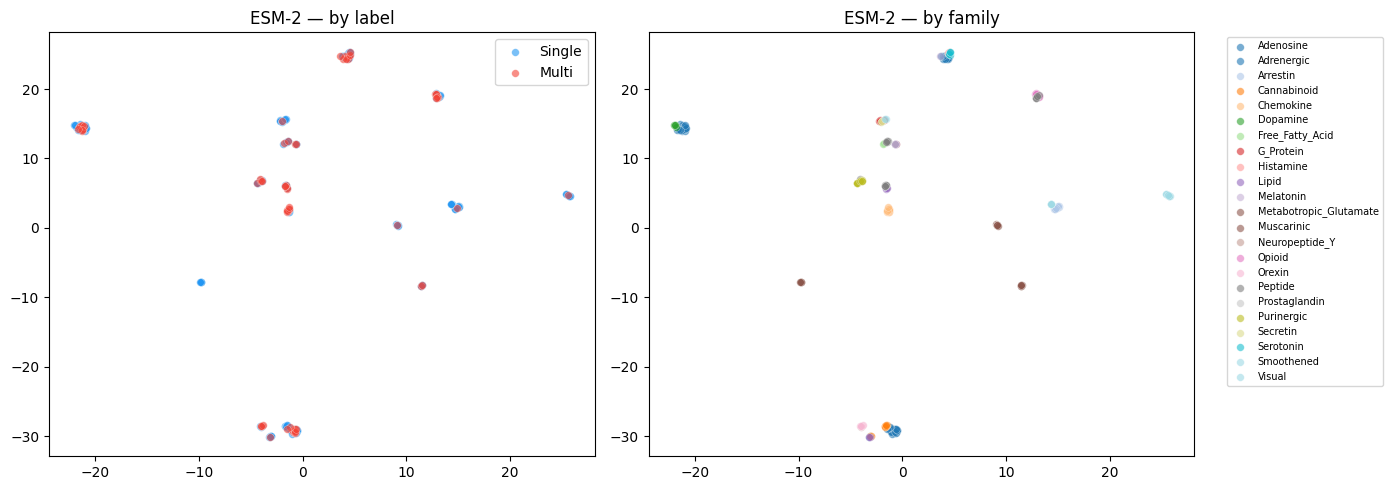

  Separation ratio: 1.007


In [33]:
plot_embedding_umap(EMBEDDING_DIR_ESM2, METADATA_CSV, title="ESM-2")

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


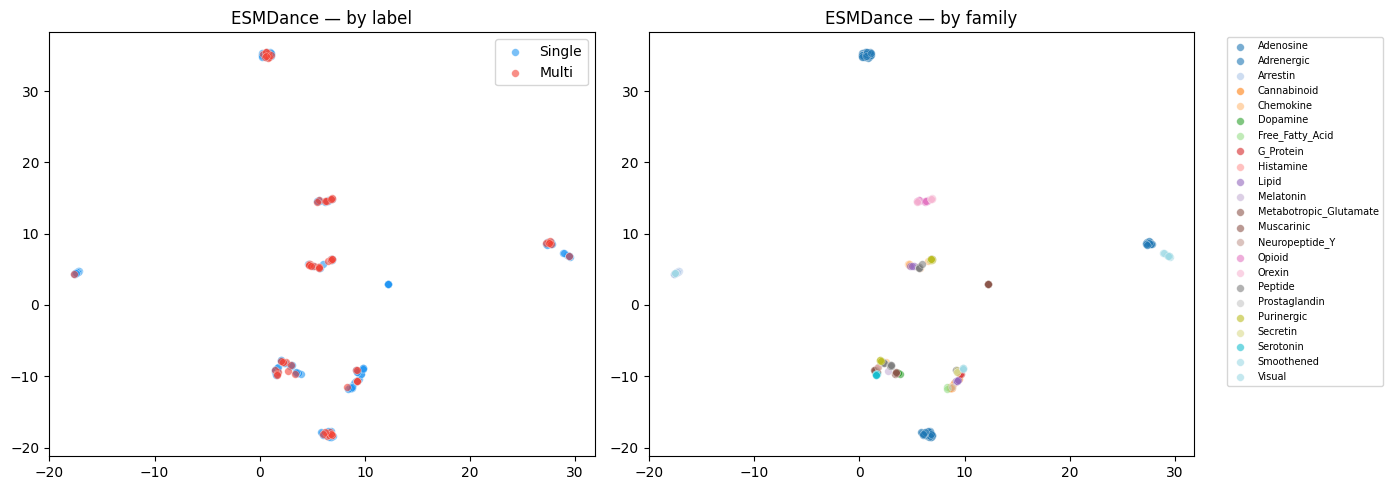

  Separation ratio: 1.011


In [34]:
plot_embedding_umap(EMBEDDING_DIR_ESMDANCE, METADATA_CSV, title="ESMDance")

## Step 5: Unsupervised Clustering Analysis

Do protein embeddings cluster by **family** even though they don't separate by multistate label?
If yes, the embeddings capture meaningful biological structure — they just don't encode
the multistate property. This strengthens our negative findings: it's not that the embeddings
are uninformative, it's that multistate behavior is not a sequence-level property.

In [13]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

def clustering_analysis(embedding_dir, metadata_csv, title=""):
    """
    Cluster embeddings and compare to family labels vs multistate labels.
    Uses ALL trajectories (not just unique receptors), so replicates of
    the same protein share the same embedding but can have different labels.
    Also reports within-receptor label disagreement.
    """
    embedding_dir = Path(embedding_dir)
    df = pd.read_csv(metadata_csv)
    df[['family']] = df[['family']].fillna("unknown")

    # Load embeddings and map to ALL trajectories
    embeddings = {}
    for receptor in df['receptor'].unique():
        safe_name = receptor.replace('~', '_')
        emb_path = embedding_dir / f"{safe_name}.npy"
        if emb_path.exists():
            embeddings[receptor] = np.load(emb_path)

    # Build per-trajectory data (all 247 rows)
    traj_data = []
    for _, row in df.iterrows():
        if row['receptor'] in embeddings:
            traj_data.append({
                'receptor': row['receptor'],
                'family': row.get('family', 'Unknown'),
                'y': int(row['y']),
                'embedding': embeddings[row['receptor']],
            })

    X = np.stack([r['embedding'] for r in traj_data])
    families = [r['family'] for r in traj_data]
    labels = [r['y'] for r in traj_data]
    receptors = [r['receptor'] for r in traj_data]

    unique_families = sorted(set(families))
    n_families = len(unique_families)
    family_int = [unique_families.index(f) for f in families]

    print(f"\n{'='*60}")
    print(f"  Clustering Analysis: {title}")
    print(f"{'='*60}")
    print(f"  {len(traj_data)} trajectories, {len(embeddings)} unique receptors, {n_families} families")
    print(f"  Embedding dim: {X.shape[1]}")

    # Within-receptor label disagreement
    traj_df = pd.DataFrame({'receptor': receptors, 'y': labels})
    receptor_label_counts = traj_df.groupby('receptor')['y'].agg(['sum', 'count'])
    receptor_label_counts['has_both'] = (
        (receptor_label_counts['sum'] > 0) &
        (receptor_label_counts['sum'] < receptor_label_counts['count'])
    )
    n_disagreement = receptor_label_counts['has_both'].sum()
    n_multi_receptor = len(receptor_label_counts[receptor_label_counts['count'] > 1])
    print(f"\n  Within-receptor label disagreement:")
    print(f"    Receptors with multiple trajectories: {n_multi_receptor}")
    print(f"    Receptors with MIXED labels (both 0 and 1): {n_disagreement}")
    if n_multi_receptor > 0:
        print(f"    Disagreement rate: {n_disagreement/n_multi_receptor*100:.1f}%")

    # K-means with k = n_families
    km = KMeans(n_clusters=n_families, random_state=42, n_init='auto')
    km_labels = km.fit_predict(X)

    # Agglomerative clustering
    agg = AgglomerativeClustering(n_clusters=n_families)
    agg_labels = agg.fit_predict(X)

    # Compare to family labels
    print(f"\n  Clustering vs Family (k={n_families}):")
    print(f"    K-means:       ARI={adjusted_rand_score(family_int, km_labels):.3f}, "
          f"NMI={normalized_mutual_info_score(family_int, km_labels):.3f}")
    print(f"    Agglomerative: ARI={adjusted_rand_score(family_int, agg_labels):.3f}, "
          f"NMI={normalized_mutual_info_score(family_int, agg_labels):.3f}")

    # Compare to multistate labels (k=2)
    km2 = KMeans(n_clusters=2, random_state=42, n_init='auto')
    km2_labels = km2.fit_predict(X)
    agg2 = AgglomerativeClustering(n_clusters=2)
    agg2_labels = agg2.fit_predict(X)

    print(f"\n  Clustering vs Multistate Label (k=2):")
    print(f"    K-means:       ARI={adjusted_rand_score(labels, km2_labels):.3f}, "
          f"NMI={normalized_mutual_info_score(labels, km2_labels):.3f}")
    print(f"    Agglomerative: ARI={adjusted_rand_score(labels, agg2_labels):.3f}, "
          f"NMI={normalized_mutual_info_score(labels, agg2_labels):.3f}")

    # Silhouette scores
    sil_family = silhouette_score(X, family_int) if n_families > 1 else 0
    sil_label = silhouette_score(X, labels) if len(set(labels)) > 1 else 0
    print(f"\n  Silhouette scores:")
    print(f"    By family:          {sil_family:.3f}")
    print(f"    By multistate label: {sil_label:.3f}")

    return {
        'X': X,
        'families': families,
        'labels': labels,
        'receptors': receptors,
        'family_int': family_int,
        'unique_families': unique_families,
    }

In [14]:
esmdance_clust = clustering_analysis(EMBEDDING_DIR_ESMDANCE, METADATA_CSV, title="ESMDance")
esm2_clust = clustering_analysis(EMBEDDING_DIR_ESM2, METADATA_CSV, title="ESM-2")


  Clustering Analysis: ESMDance
  246 trajectories, 143 unique receptors, 24 families
  Embedding dim: 480

  Within-receptor label disagreement:
    Receptors with multiple trajectories: 69
    Receptors with MIXED labels (both 0 and 1): 36
    Disagreement rate: 52.2%

  Clustering vs Family (k=24):
    K-means:       ARI=0.671, NMI=0.847
    Agglomerative: ARI=0.648, NMI=0.822

  Clustering vs Multistate Label (k=2):
    K-means:       ARI=-0.054, NMI=0.027
    Agglomerative: ARI=-0.041, NMI=0.017

  Silhouette scores:
    By family:          0.430
    By multistate label: -0.036

  Clustering Analysis: ESM-2
  246 trajectories, 143 unique receptors, 24 families
  Embedding dim: 1280

  Within-receptor label disagreement:
    Receptors with multiple trajectories: 69
    Receptors with MIXED labels (both 0 and 1): 36
    Disagreement rate: 52.2%

  Clustering vs Family (k=24):
    K-means:       ARI=0.631, NMI=0.832
    Agglomerative: ARI=0.655, NMI=0.847

  Clustering vs Multistate

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


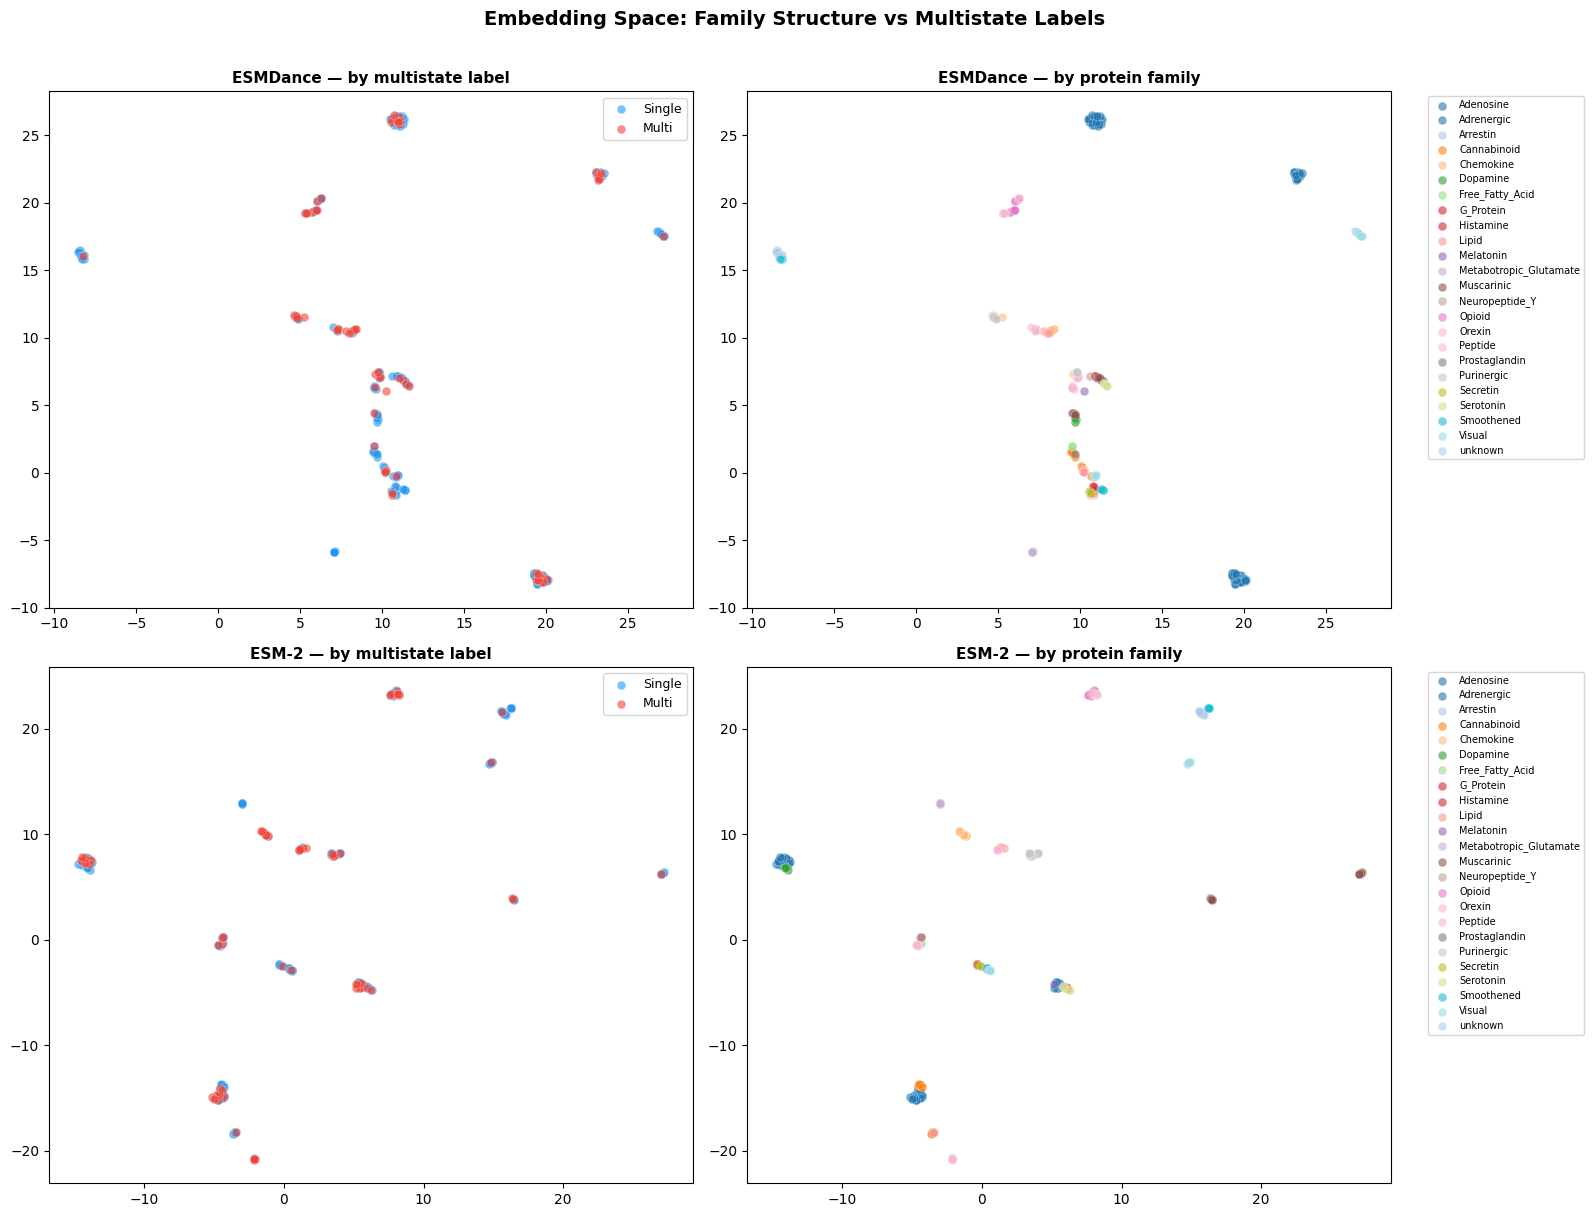

If family clusters are visible but multistate labels are not separated,
the embeddings capture biology but multistate behavior is not a sequence-level property.


In [15]:
# UMAP colored by family vs label — side by side for both models
import matplotlib.pyplot as plt
try:
    from umap import UMAP
except ImportError:
    print("pip install umap-learn")
    raise

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, (data, model_name) in enumerate([
    (esmdance_clust, 'ESMDance'),
    (esm2_clust, 'ESM-2'),
]):
    reducer = UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(data['X'])
    y = np.array(data['labels'])
    families = data['families']
    unique_fams = data['unique_families']

    # Color by label
    ax = axes[row, 0]
    for label, color, name in [(0, '#2196F3', 'Single'), (1, '#F44336', 'Multi')]:
        mask = y == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name,
                   alpha=0.6, s=40, edgecolors='white', linewidth=0.3)
    ax.set_title(f"{model_name} — by multistate label", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

    # Color by family
    ax = axes[row, 1]
    cmap = plt.cm.tab20(np.linspace(0, 1, len(unique_fams)))
    for i, fam in enumerate(unique_fams):
        mask = np.array([f == fam for f in families])
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[cmap[i]], label=fam,
                   alpha=0.6, s=40, edgecolors='white', linewidth=0.3)
    ax.set_title(f"{model_name} — by protein family", fontsize=11, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.suptitle('Embedding Space: Family Structure vs Multistate Labels',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'embedding_clustering_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print("If family clusters are visible but multistate labels are not separated,")
print("the embeddings capture biology but multistate behavior is not a sequence-level property.")

## Step 6: Label Robustness Analysis

Our ground-truth labels are generated via unsupervised learning (TICA + k-means + thresholds).
How sensitive are the labels to the chosen thresholds?

We sweep the dominant cluster fraction threshold and silhouette threshold
to quantify how many labels change, identifying trajectories near the decision boundary.

In [16]:
df = pd.read_csv(METADATA_CSV)
print(f"Trajectories: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Check if we have the raw labeling metrics
has_metrics = 'dominant_cluster_frac' in df.columns and 'silhouette' in df.columns
if has_metrics:
    print(f"\nLabel metrics available:")
    print(f"  dominant_cluster_frac: {df['dominant_cluster_frac'].describe().to_dict()}")
    print(f"  silhouette: {df['silhouette'].describe().to_dict()}")
else:
    print("\nLabel metrics (dominant_cluster_frac, silhouette) not in metadata.")
    print("Checking base dataset for these columns...")
    # Try loading the original base dataset that has these columns
    for candidate in [
        '../data/processed/data_processed_v3_base_dataset_deduped.csv',
    ]:
        if Path(candidate).exists():
            base_df = pd.read_csv(candidate)
            if 'dominant_cluster_frac' in base_df.columns:
                print(f"  Found in: {candidate}")
                # Merge metrics into df
                merge_cols = ['receptor', 'simID', 'rep', 'dominant_cluster_frac', 'silhouette']
                available = [c for c in merge_cols if c in base_df.columns]
                df = df.merge(base_df[available], on=['receptor', 'simID', 'rep'], how='left')
                has_metrics = True
                break

if not has_metrics:
    print("  Could not find label metrics. Skipping robustness analysis.")

Trajectories: 247
Columns: ['receptor', 'rep', 'simID', 'y', 'family', 'label', 'traj_file', 'top_file', 'graph_file', 'scalar_file', 'tica_file', 'n_frames_total', 'traj_id']

Label metrics (dominant_cluster_frac, silhouette) not in metadata.
Checking base dataset for these columns...
  Found in: ../data/processed/data_processed_v3_base_dataset_deduped.csv


Original thresholds: dominant<=0.75, silhouette>=0.5
Original labels: 71 multi / 176 single


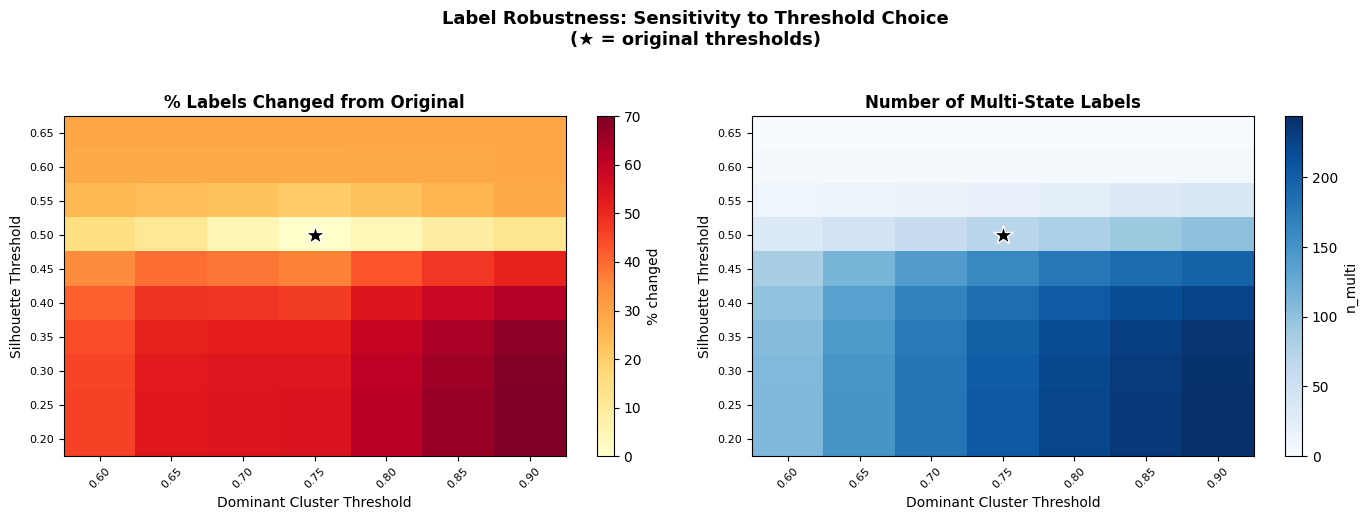

In [17]:
if has_metrics:
    # Original thresholds used in labeling
    ORIG_DOM_THRESH = 0.75
    ORIG_SIL_THRESH = 0.50

    def compute_labels(df, dom_thresh, sil_thresh):
        """Recompute labels with given thresholds."""
        return (
            (df['dominant_cluster_frac'] <= dom_thresh) &
            (df['silhouette'].notna()) &
            (df['silhouette'] >= sil_thresh)
        ).astype(int)

    # Sweep dominant threshold
    dom_thresholds = np.arange(0.60, 0.95, 0.05)
    sil_thresholds = np.arange(0.20, 0.70, 0.05)

    original_labels = compute_labels(df, ORIG_DOM_THRESH, ORIG_SIL_THRESH)
    n_orig_multi = original_labels.sum()

    print(f"Original thresholds: dominant<={ORIG_DOM_THRESH}, silhouette>={ORIG_SIL_THRESH}")
    print(f"Original labels: {n_orig_multi} multi / {len(df)-n_orig_multi} single")

    # Sweep both thresholds
    sweep_results = []
    for dt in dom_thresholds:
        for st in sil_thresholds:
            new_labels = compute_labels(df, dt, st)
            n_changed = (new_labels != original_labels).sum()
            n_multi = new_labels.sum()
            sweep_results.append({
                'dom_thresh': dt,
                'sil_thresh': st,
                'n_multi': int(n_multi),
                'n_single': int(len(df) - n_multi),
                'n_changed': int(n_changed),
                'pct_changed': n_changed / len(df) * 100,
            })

    sweep_df = pd.DataFrame(sweep_results)

    # Heatmap of % changed
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Heatmap: % labels changed
    pivot = sweep_df.pivot(index='sil_thresh', columns='dom_thresh', values='pct_changed')
    im = axes[0].imshow(pivot.values, cmap='YlOrRd', aspect='auto',
                         origin='lower', vmin=0)
    axes[0].set_xticks(range(len(dom_thresholds)))
    axes[0].set_xticklabels([f'{t:.2f}' for t in dom_thresholds], rotation=45, fontsize=8)
    axes[0].set_yticks(range(len(sil_thresholds)))
    axes[0].set_yticklabels([f'{t:.2f}' for t in sil_thresholds], fontsize=8)
    axes[0].set_xlabel('Dominant Cluster Threshold')
    axes[0].set_ylabel('Silhouette Threshold')
    axes[0].set_title('% Labels Changed from Original', fontweight='bold')
    plt.colorbar(im, ax=axes[0], label='% changed')

    # Mark original thresholds
    orig_x = np.argmin(np.abs(dom_thresholds - ORIG_DOM_THRESH))
    orig_y = np.argmin(np.abs(sil_thresholds - ORIG_SIL_THRESH))
    axes[0].plot(orig_x, orig_y, 'k*', markersize=15, markeredgecolor='white')

    # Heatmap: n_multi
    pivot_multi = sweep_df.pivot(index='sil_thresh', columns='dom_thresh', values='n_multi')
    im2 = axes[1].imshow(pivot_multi.values, cmap='Blues', aspect='auto',
                          origin='lower')
    axes[1].set_xticks(range(len(dom_thresholds)))
    axes[1].set_xticklabels([f'{t:.2f}' for t in dom_thresholds], rotation=45, fontsize=8)
    axes[1].set_yticks(range(len(sil_thresholds)))
    axes[1].set_yticklabels([f'{t:.2f}' for t in sil_thresholds], fontsize=8)
    axes[1].set_xlabel('Dominant Cluster Threshold')
    axes[1].set_ylabel('Silhouette Threshold')
    axes[1].set_title('Number of Multi-State Labels', fontweight='bold')
    plt.colorbar(im2, ax=axes[1], label='n_multi')
    axes[1].plot(orig_x, orig_y, 'k*', markersize=15, markeredgecolor='white')

    plt.suptitle('Label Robustness: Sensitivity to Threshold Choice\n(★ = original thresholds)',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'label_robustness_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

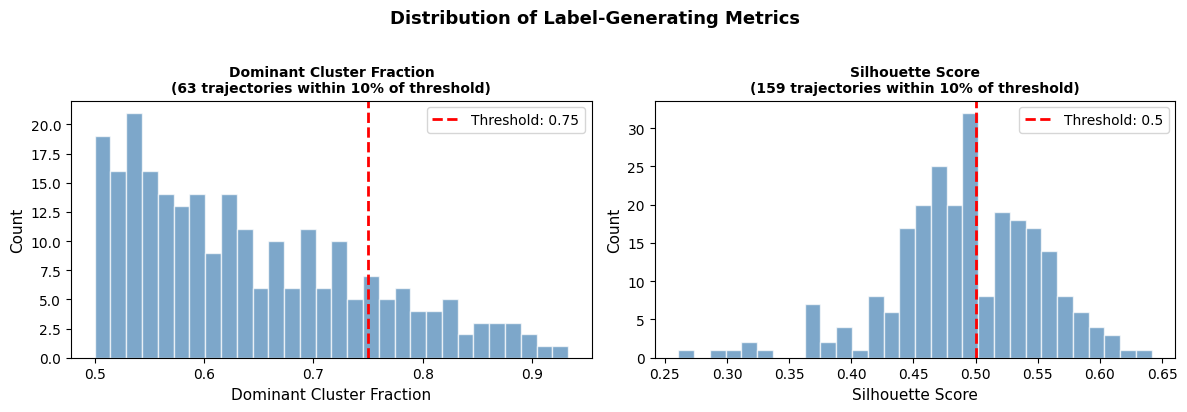


Borderline trajectories (within 10% of either threshold): 182/247 (73.7%)
  Multi-state: 57.0
  Single-state: 125


In [19]:
if has_metrics:
    # Distribution of label-generating metrics
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, thresh, label in [
        (axes[0], 'dominant_cluster_frac', ORIG_DOM_THRESH, 'Dominant Cluster Fraction'),
        (axes[1], 'silhouette', ORIG_SIL_THRESH, 'Silhouette Score'),
    ]:
        vals = df[col].dropna()
        ax.hist(vals, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
        ax.axvline(x=thresh, color='red', linestyle='--', linewidth=2,
                   label=f'Threshold: {thresh}')
        ax.set_xlabel(label, fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.legend()

        # Count trajectories near the boundary (within 10% of threshold)
        margin = thresh * 0.10
        near_boundary = ((vals >= thresh - margin) & (vals <= thresh + margin)).sum()
        ax.set_title(f'{label}\n({near_boundary} trajectories within 10% of threshold)',
                     fontsize=10, fontweight='bold')

    plt.suptitle('Distribution of Label-Generating Metrics',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'label_metric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Identify borderline trajectories
    dom_margin = ORIG_DOM_THRESH * 0.10
    sil_margin = ORIG_SIL_THRESH * 0.10
    borderline = df[
        (df['dominant_cluster_frac'].between(ORIG_DOM_THRESH - dom_margin, ORIG_DOM_THRESH + dom_margin)) |
        (df['silhouette'].between(ORIG_SIL_THRESH - sil_margin, ORIG_SIL_THRESH + sil_margin))
    ]
    print(f"\nBorderline trajectories (within 10% of either threshold): "
          f"{len(borderline)}/{len(df)} ({len(borderline)/len(df)*100:.1f}%)")
    print(f"  Multi-state: {borderline['y'].sum()}")
    print(f"  Single-state: {(borderline['y']==0).sum()}")

## Summary
|Approach | Features | Dim | Source | AUROC | 
|---|---|---|---|---|
| TCN |Scalar (RMSD, Rg, TM3-TM6) | 3 | Early (50%) | 0.500 |
| TCN | TICA projections | 5 | Early (50%) | 0.500 | 
| TCN | Combined (scalar+graph+structural) | 58 | Early (50%) | 0.500 | 
| LR/RF/MLP | ESM-2 embeddings | 1280 | Sequence | 0.500 | 
| LR/RF/MLP | ESMDance embeddings | 480 | Sequence (dynamics-aware) | 0.500 | 
| TCN | Sanity check (TICA+clustering) | 7 | Full traj (50%) | 0.831 |
| TCN | Sanity check (TICA+clustering) | 7 | Full traj (90%) | 0.956 |